In [341]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Data load karo
df = pd.read_csv('C:/Users/TEJ/Desktop/Excel/python file/flight-delay-project/india_flight_delays_2025.csv')

# first 5 rows
df.head()


,FlightDate,Airline,AirlineCode,FlightNumber,Origin,OriginCity,Dest,DestCity,DayOfWeek,CRSDepTime,DepTime,DepDelay,CRSArrTime,ArrTime,ArrDelay,Cancelled,Distance_KM,AirTime_Min
0,2025-01-04,AirAsia India,I5,I5484,LKO,Lucknow,COK,Kochi,Saturday,16:50,18:50,120.0,18:41,20:36,115.0,0,1226,91
1,2025-01-05,Akasa Air,QP,QP921,AMD,Ahmedabad,BLR,Bengaluru,Sunday,12:15,12:17,2.0,13:46,13:48,2.0,0,954,71
2,2025-01-05,Vistara,UK,UK910,HYD,Hyderabad,MAA,Chennai,Sunday,15:50,16:00,10.0,16:49,16:59,10.0,0,520,39
3,2025-01-07,IndiGo,6E,6E477,BOM,Mumbai,JAI,Jaipur,Tuesday,08:30,08:30,0.0,09:54,09:49,-5.0,0,870,64
4,2025-01-09,Air India,AI,AI749,BOM,Mumbai,MAA,Chennai,Thursday,07:30,07:55,25.0,09:06,09:31,25.0,0,1030,76


In [342]:
# totela rows/columns how much 
print("Shape:", df.shape)

# Column names ane data types
df.info()

# show the which missing value their
df.isnull().sum()

Shape: (190, 18)
<class 'pandas.DataFrame'>
RangeIndex: 190 entries, 0 to 189
Data columns (total 18 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   FlightDate    190 non-null    str    
 1   Airline       190 non-null    str    
 2   AirlineCode   190 non-null    str    
 3   FlightNumber  190 non-null    str    
 4   Origin        190 non-null    str    
 5   OriginCity    190 non-null    str    
 6   Dest          190 non-null    str    
 7   DestCity      190 non-null    str    
 8   DayOfWeek     190 non-null    str    
 9   CRSDepTime    190 non-null    str    
 10  DepTime       185 non-null    str    
 11  DepDelay      185 non-null    float64
 12  CRSArrTime    190 non-null    str    
 13  ArrTime       185 non-null    str    
 14  ArrDelay      185 non-null    float64
 15  Cancelled     190 non-null    int64  
 16  Distance_KM   190 non-null    int64  
 17  AirTime_Min   190 non-null    int64  
dtypes: float64(2), int64(3),

FlightDate      0
Airline         0
AirlineCode     0
FlightNumber    0
Origin          0
OriginCity      0
Dest            0
DestCity        0
DayOfWeek       0
CRSDepTime      0
DepTime         5
DepDelay        5
CRSArrTime      0
ArrTime         5
ArrDelay        5
Cancelled       0
Distance_KM     0
AirTime_Min     0
dtype: int64

In [343]:
avg_delay = df['DepDelay'].mean()
print("Average Departure Delay:", round(avg_delay, 2), "minutes")

Average Departure Delay: 16.95 minutes


In [344]:
df.groupby('Airline')['DepDelay'].mean().sort_values(ascending=False)

Airline
AirAsia India    24.851852
Akasa Air        22.280000
Air India        19.090909
SpiceJet         18.655172
IndiGo           13.875000
Go First         10.791667
Vistara           6.260870
Name: DepDelay, dtype: float64

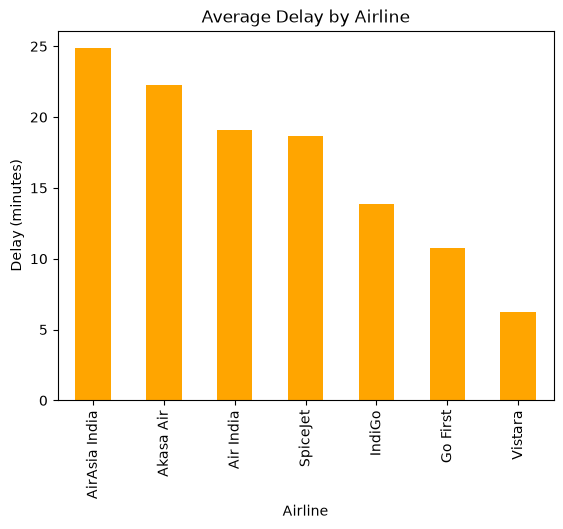

In [345]:
import matplotlib.pyplot as plt

df.groupby('Airline')['DepDelay'].mean().sort_values(ascending=False).plot(kind='bar', color='orange')
plt.title('Average Delay by Airline')
plt.ylabel('Delay (minutes)')
plt.xlabel('Airline')
plt.show()

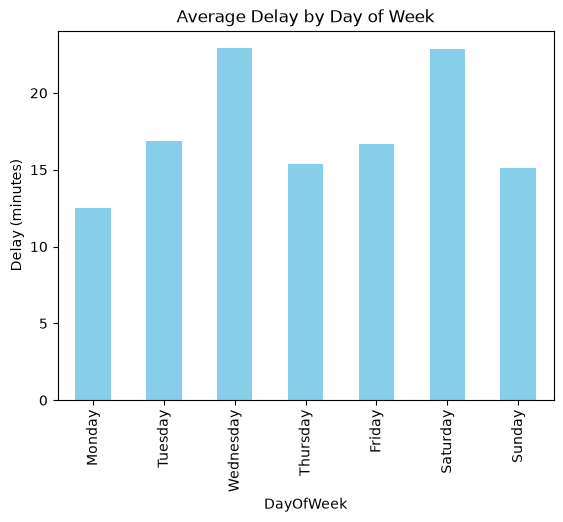

In [346]:
day_order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']

df.groupby('DayOfWeek')['DepDelay'].mean().reindex(day_order).plot(kind='bar', color='skyblue')
plt.title('Average Delay by Day of Week')
plt.ylabel('Delay (minutes)')
plt.show()

In [347]:
arrivals = df.groupby(['Dest','DestCity']).size().reset_index(name='Total_Arrivals')
arrivals = arrivals.sort_values('Total_Arrivals', ascending=False)
print(arrivals)

   Dest   DestCity  Total_Arrivals
10  MAA    Chennai              28
4   COK      Kochi              18
0   AMD  Ahmedabad              17
3   CCU    Kolkata              17
8   JAI     Jaipur              17
9   LKO    Lucknow              17
6   GOI        Goa              16
11  PNQ       Pune              15
1   BLR  Bengaluru              13
7   HYD  Hyderabad              12
5   DEL      Delhi              11
2   BOM     Mumbai               9


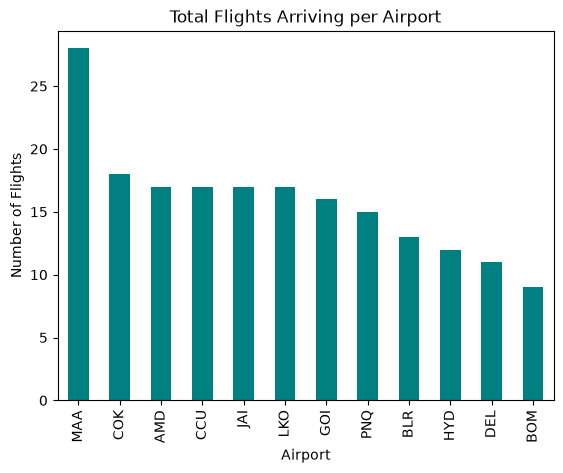

In [348]:
arrivals.set_index('Dest')['Total_Arrivals'].plot(kind='bar', color='teal')
plt.title('Total Flights Arriving per Airport')
plt.ylabel('Number of Flights')
plt.xlabel('Airport')
plt.show()

In [349]:
flights_to_top_airport = df[df['Dest'] == top_airport][['FlightNumber','Airline','OriginCity','DepDelay']]
print(flights_to_top_airport)

    FlightNumber        Airline OriginCity  DepDelay
2          UK910        Vistara  Hyderabad      10.0
4          AI749      Air India     Mumbai      25.0
10         AI338      Air India      Delhi       NaN
11         I5410  AirAsia India      Delhi       2.0
21         SG353       SpiceJet     Mumbai      30.0
23         I5282  AirAsia India     Mumbai      40.0
26         QP305      Akasa Air      Delhi      25.0
34         QP613      Akasa Air     Mumbai      40.0
43         QP719      Akasa Air     Mumbai       2.0
56         G8848       Go First      Delhi      10.0
58         QP957      Akasa Air  Hyderabad      12.0
60         G8741       Go First     Jaipur      -3.0
63         AI938      Air India      Kochi       2.0
74         6E241         IndiGo  Hyderabad       0.0
97         AI229      Air India    Lucknow       0.0
103        QP290      Akasa Air     Jaipur      35.0
131        QP509      Akasa Air     Mumbai       0.0
140        AI126      Air India     Mumbai    